# PIMA INDIANS DIABETES - CLASSIFICATION

## Version 5 - Hyperparameters Tuning

### Khai báo thư viện nâng cao
- Sử dụng Pipeline để tránh rò rỉ dữ liệu (data leakage) và SimpleImputer để xử lý giá trị 0.

In [441]:
import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from sklearn.base import BaseEstimator, TransformerMixin
from scipy.stats import uniform, randint

## 1. Nạp dữ liệu

In [442]:
data_path = os.path.join(os.getcwd(), "..", "data", "pima-indians-diabetes.csv")
col_names = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI","DiabetesPedigreeFunction", "Age", "Outcome"]

df = pd.read_csv(data_path, header=None, names=col_names)
print(f"Đã nạp {len(df)} dòng dữ liệu.")
print(f"Shape: {df.shape}")
df.head(10)

Đã nạp 768 dòng dữ liệu.
Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


## 2. Chia tập dữ liệu (Split Data)

- Chia dữ liệu: Tách cột mục tiêu Outcome (nhãn y) và các cột đặc trưng (X). Sau đó chia thành tập huấn luyện (70%) và tập kiểm tra (30%).

- BasePreprocessor: Đây là một lớp tùy chỉnh (Custom Transformer) dùng để xử lý các giá trị bằng 0 vô lý. Cụ thể, các giá trị 0 ở các cột như Glucose, BloodPressure, BMI... sẽ được thay thế bằng NaN để sau này có thể xử lý bằng phương pháp điền giá trị trung vị (median).

In [443]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [444]:
class BasePreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X[self.cols] = X[self.cols].replace(0, np.nan)
        return X

- Hai đặc trưng mới được tạo ra:

  - BMI_Age: Tích của chỉ số khối cơ thể (BMI) và Tuổi (Age). Giả định rằng sự kết hợp giữa béo phì và tuổi tác cao làm tăng nguy cơ tiểu đường một cách đáng kể.

  - Glucose_BMI: Tích của lượng Đường trong máu (Glucose) và BMI. Đây là sự kết hợp giữa hai yếu tố nguy cơ hàng đầu.

In [445]:
class FeatureEngineering(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # Feature mới
        X["BMI_Age"] = X["BMI"] * X["Age"]
        X["Glucose_BMI"] = X["Glucose"] * X["BMI"]
        
        return X

- BaseEstimator, TransformerMixin: Việc kế thừa hai lớp này giúp LogTransform có thể sử dụng được các phương thức như fit_transform() và dễ dàng tích hợp vào một Pipeline của Scikit-learn.

- __init__(self, col_idx=4): Khởi tạo chỉ số cột cần biến đổi. Trong bộ dữ liệu Pima, cột thứ 4 (tính từ 0) thường là cột Insulin.

- fit(self, X, y=None): Không cần học tham số gì từ dữ liệu huấn luyện, nên hàm này chỉ đơn giản là return self.

- transform(self, X):

  - X.copy(): Đảm bảo không thay đổi trực tiếp trên mảng dữ liệu gốc.

  - np.log1p(...): Đây là hàm tính ln(1+x). Việc dùng log1p thay vì log thông thường giúp tránh lỗi tính toán khi dữ liệu có giá trị bằng 0 (vì log(0) là không xác định).

In [446]:
class LogTransform(BaseEstimator, TransformerMixin):
    def __init__(self, col_idx=4):
        self.col_idx = col_idx

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X[:, self.col_idx] = np.log1p(X[:, self.col_idx])
        return X

## 3. Huấn luyện mô hình Baseline (Logistic Regression)

- Danh sách mô hình: Khởi tạo 4 thuật toán phổ biến:

  - LogisticRegression: Mô hình tuyến tính cơ bản.

  - RandomForestClassifier: Mô hình dựa trên cây quyết định (mạnh mẽ với dữ liệu bảng).

  - SVC: Mô hình Support Vector Machine.

  - KNeighborsClassifier: Mô hình dựa trên khoảng cách.
- base: Sử dụng BasePreprocessor để xử lý các giá trị 0 không hợp lệ thành NaN.

- imputer: Điền các giá trị thiếu bằng phương pháp trung vị (median).

- log: Áp dụng LogTransform (thường là cho cột Insulin) để giảm độ lệch của dữ liệu.

- scaler: Sử dụng StandardScaler để đưa dữ liệu về cùng một thang đo.

- model: Mô hình mặc định ban đầu là LogisticRegression.

In [447]:
pipeline = Pipeline([
    ('base', BasePreprocessor()),
    #('feature', FeatureEngineering()),
    ('imputer', SimpleImputer(strategy='median')),
    ('log', LogTransform()),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

# param_grid = [ # GridSearchCV

#     # 🔹 Logistic Regression
#     {
#         'model': [LogisticRegression(max_iter=1000)],
#         'model__C': [0.01, 0.1, 1, 10]
#     },

#     # 🔹 Random Forest
#     {
#         'model': [RandomForestClassifier()],
#         'model__n_estimators': [100, 200],
#         'model__max_depth': [None, 5, 10]
#     },

#     # 🔹 SVM
#     {
#         'model': [SVC()],
#         'model__C': [0.1, 1, 10],
#         'model__kernel': ['rbf', 'linear']
#     },

#     # 🔹 KNN
#     {
#         'model': [KNeighborsClassifier()],
#         'model__n_neighbors': [3, 5, 7],
#         'model__weights': ['uniform', 'distance']
#     }
# ]

param_dist = [ # RandomizedSearchCV

    # 🔹 Logistic
    {
        'model': [LogisticRegression(max_iter=1000)],
        'model__C': uniform(0.01, 10)
    },

    # 🔹 Random Forest
    {
        'model': [RandomForestClassifier()],
        'model__n_estimators': randint(100, 500),
        'model__max_depth': randint(3, 15)
    },

    # 🔹 SVM
    {
        'model': [SVC()],
        'model__C': uniform(0.1, 10),
        'model__kernel': ['rbf', 'linear']
    },

    # 🔹 KNN
    {
        'model': [KNeighborsClassifier()],
        'model__n_neighbors': randint(3, 15),
        'model__weights': ['uniform', 'distance']
    }
]

- Hiệu quả thời gian: Đặt n_iter=100, nghĩa là máy sẽ chọn ngẫu nhiên 100 tổ hợp tham số để thử nghiệm thay vì thử toàn bộ mọi khả năng (GridSearch), giúp tiết kiệm tài nguyên tính toán.

- cv=cv: Sử dụng StratifiedKFold với 5 lần chia dữ liệu để đảm bảo kết quả đánh giá ổn định và khách quan trên các nhóm nhãn khác nhau.

- scoring='f1': Mục tiêu tối ưu hóa là chỉ số F1-score, giúp cân bằng giữa độ chính xác (Precision) và độ triệu hồi (Recall), rất quan trọng trong bài toán y tế.

In [448]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# grid = GridSearchCV(
#     pipeline,
#     param_grid,
#     cv=cv,
#     scoring='f1',
#     n_jobs=-1,
#     verbose=2
# )

# grid.fit(X_train, y_train)

random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=100,                # số lần random thử
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'model': [LogisticRegre...max_iter=1000)], 'model__C': <scipy.stats....0015E89A3ECC0>}, {'model': [RandomForestClassifier()], 'model__max_depth': <scipy.stats....0015E86282720>, 'model__n_estimators': <scipy.stats....0015E89A3F230>}, ...]"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the sam

In [449]:
results = pd.DataFrame(random_search.cv_results_)

results['model_name'] = results['param_model'].apply(lambda x: type(x).__name__) # convert tên model

display(results[['model_name', 'mean_test_score', 'param_model__C', 'param_model__n_estimators', 'param_model__max_depth', 'param_model__kernel', 'param_model__n_neighbors', 'param_model__weights']].sort_values(by='mean_test_score', ascending=False))

,model_name,mean_test_score,param_model__C,param_model__n_estimators,param_model__max_depth,param_model__kernel,param_model__n_neighbors,param_model__weights
35,RandomForestClassifier,0.657714,NaN,351.0,11.0,NaN,NaN,NaN
44,RandomForestClassifier,0.655441,NaN,140.0,9.0,NaN,NaN,NaN
64,RandomForestClassifier,0.654517,NaN,233.0,11.0,NaN,NaN,NaN
25,RandomForestClassifier,0.652711,NaN,153.0,8.0,NaN,NaN,NaN
31,RandomForestClassifier,0.652255,NaN,351.0,9.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
42,KNeighborsClassifier,0.614078,NaN,NaN,NaN,NaN,5.0,uniform
13,KNeighborsClassifier,0.611655,NaN,NaN,NaN,NaN,5.0,distance
97,KNeighborsClassifier,0.611655,NaN,NaN,NaN,NaN,5.0,distance
85,KNeighborsClassifier,0.600983,NaN,NaN,NaN,NaN,8.0,uniform


## 4. Đánh giá chi tiết

- Trục tung (Actual): Giá trị thực tế của bệnh nhân.

- Trục hoành (Predicted): Giá trị mô hình dự đoán.

- Nó giúp nhận diện ngay lập tức mô hình đang đoán sai ở đâu: Nhầm người khỏe thành có bệnh (False Positive) hay bỏ sót người bệnh (False Negative).

In [450]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(y_test, y_pred, title):
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["No Diabetes", "Diabetes"],
                yticklabels=["No Diabetes", "Diabetes"])

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix - " + title)
    plt.tight_layout()
    plt.show()

- Mục tiêu: Trong danh sách hàng trăm tổ hợp tham số đã thử, đoạn này lọc ra cấu hình có điểm mean_test_score (F1-score trung bình khi cross-validation) cao nhất cho mỗi loại mô hình (ví dụ: 1 bản Random Forest tốt nhất, 1 bản SVM tốt nhất...).

- Kết quả: Có một danh sách ngắn gồm 4 ứng cử viên xuất sắc nhất đại diện cho 4 thuật toán.

In [451]:
results['model_name'] = results['param_model'].apply(lambda x: type(x).__name__)

best_per_model = results.sort_values(
    by="mean_test_score",
    ascending=False
).groupby("model_name").head(1)

- pipeline.set_params(**params): Cấu hình lại toàn bộ Pipeline (từ tiền xử lý đến mô hình) với bộ tham số tối ưu vừa tìm được.

- pipeline.fit(X_train, y_train): Huấn luyện lại mô hình trên toàn bộ tập huấn luyện. Điều này quan trọng vì khi Tuning, mô hình chỉ học trên từng phần dữ liệu (K-Fold), còn bây giờ nó được học trên 100% dữ liệu train để đạt sức mạnh tối đa.

- Dự báo và Tính điểm: Dự báo trên tập X_test (dữ liệu mô hình chưa từng thấy) để tính Accuracy và F1-score thực tế.

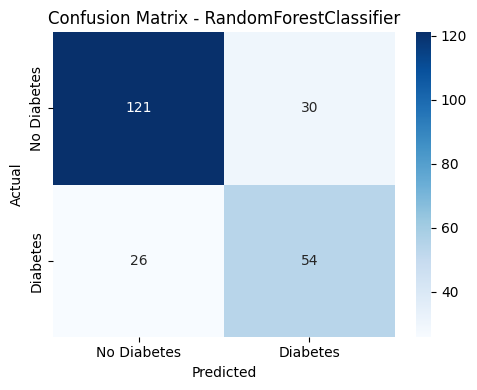

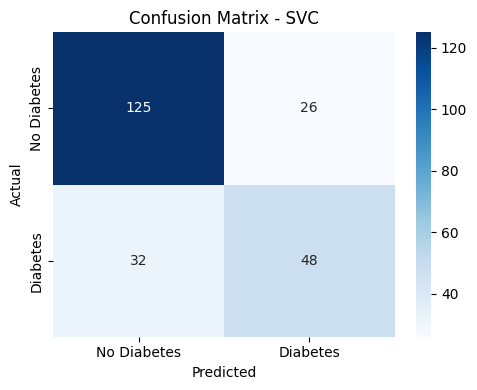

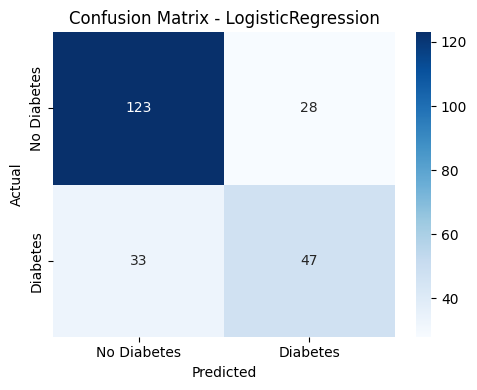

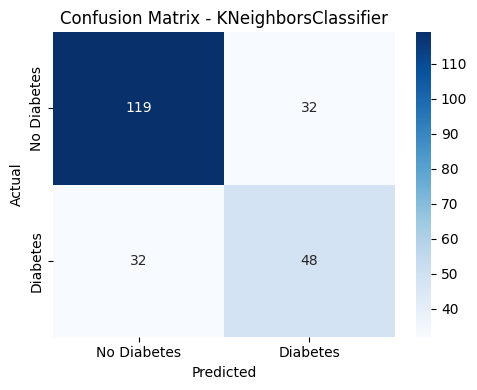

In [452]:
final_results = []

for i in best_per_model.index:
    params = results.loc[i, 'params']

    # set params vào pipeline
    pipeline.set_params(**params)

    # train lại trên full train
    pipeline.fit(X_train, y_train)

    # predict
    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    final_results.append({
        "model": type(params['model']).__name__,
        "cv_f1": round(results.loc[i, 'mean_test_score'], 4),
        "test_acc": round(acc, 4),
        "test_f1": round(f1, 4),
        "params": {k: v for k, v in params.items() if k != 'model'}
    })
    
    plot_confusion_matrix(y_test, y_pred, type(params['model']).__name__)

- cv_f1 vs test_f1: Nếu hai chỉ số này gần bằng nhau, mô hình có tính ổn định cao. Nếu cv_f1 cao nhưng test_f1 thấp, mô hình đang bị quá khớp.

- sns.barplot: Vẽ biểu đồ cột để thấy rõ sự chênh lệch hiệu suất giữa các mô hình đã được tinh chỉnh (Tuned).

- display.max_colwidth: Mở rộng độ rộng hiển thị để lưu lại chính xác bộ thông số (params), phục vụ cho việc tái lập mô hình trong Version 6.

In [453]:
df_final = pd.DataFrame(final_results)

df_final = df_final.sort_values(by="test_f1", ascending=False)

pd.set_option('display.max_colwidth', None) # show full params
df_final

,model,cv_f1,test_acc,test_f1,params
0,RandomForestClassifier,0.6577,0.7576,0.6585,"{'model__max_depth': 11, 'model__n_estimators': 351}"
1,SVC,0.6516,0.7489,0.6234,"{'model__C': 3.1087830981676965, 'model__kernel': 'rbf'}"
2,LogisticRegression,0.6488,0.7359,0.6065,{'model__C': 0.16966252220214195}
3,KNeighborsClassifier,0.6460,0.7229,0.6000,"{'model__n_neighbors': 11, 'model__weights': 'distance'}"


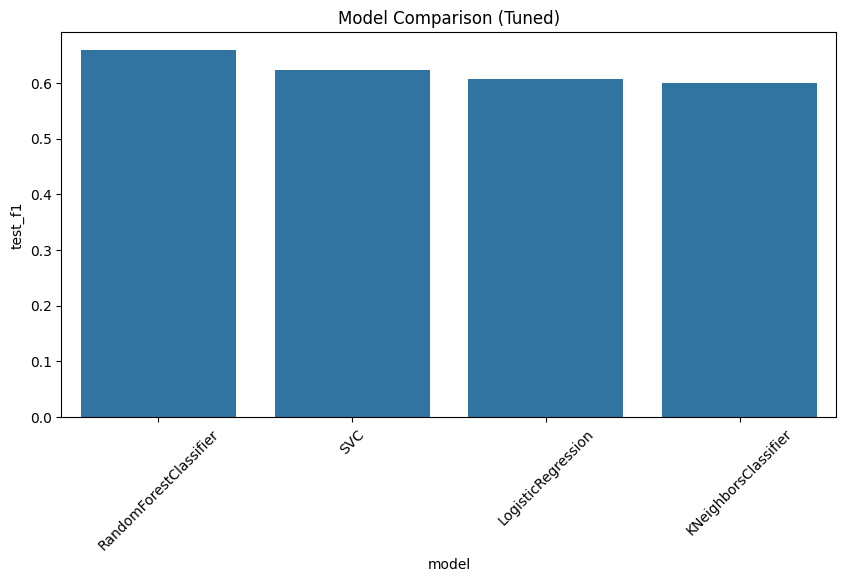

In [454]:
plt.figure(figsize=(10,5))
sns.barplot(data=df_final, x="model", y="test_f1")
plt.xticks(rotation=45)
plt.title("Model Comparison (Tuned)")
plt.show()

### Tổng kết Version 5:
- Mô hình: Tiếp tục thử nghiệm và so sánh bộ 4 thuật toán (Logistic, RandomForest, SVM, KNN).

- Kỹ thuật tối ưu hóa: 
  - Sử dụng RandomizedSearchCV để thực hiện tìm kiếm ngẫu nhiên trong không gian tham số rộng lớn (100 lượt thử cho mỗi mô hình).

  - Kết hợp với StratifiedKFold (5-fold) để đảm bảo quá trình đánh giá tham số khách quan và không bị ảnh hưởng bởi sự mất cân bằng nhãn.

  - Mục tiêu tối ưu hóa tập trung vào chỉ số F1-score.
- Random Forest: Thử nghiệm số lượng cây (n_estimators) và độ sâu (max_depth) trong dải rộng.

- SVM: Tinh chỉnh hệ số phạt C và loại nhân (kernel) để tìm ranh giới phân loại tốt nhất.

- KNN & Logistic: Tối ưu hóa các tham số về khoảng cách và cường độ điều quy.

- Kết quả: Tìm ra được thuật toán tốt nhất sau khi đã được tinh chỉnh.

  - Hiệu suất của các mô hình đều có sự cải thiện rõ rệt so với bản baseline.

  - Random Forest sau khi tuning khẳng định vị thế dẫn đầu với chỉ số test_f1 vượt trội, chuẩn bị cho việc đóng gói mô hình cuối cùng ở Version 6.